In [4]:
import pandas as pd
from pathlib import Path

root = Path.cwd().parents[2]  # cwd is .../ProjectGroup5/src/data/True_power_generation_in_2022
                               # [0] = src/data, [1] = src, [2] = ProjectGroup5

df_orange = pd.read_csv(root / 'src/data/model_output/orange - model/orange_power_forecast_2022_daily_clean.csv')
df_actual = pd.read_csv(root / 'src/data/True_power_generation_in_2022/wind-2022-uur-data-reformated.csv')

print(df_orange.head())
print(df_actual.head())

         date  Orange Model - Predicted Wind Power (kWh)
0  2022-01-01                                   25395300
1  2022-01-02                                   42542000
2  2022-01-03                                   42318000
3  2022-01-04                                   20342300
4  2022-01-05                                   37900700
         date  Actual Energy created (kW)
0  2022-01-01                    52426429
1  2022-01-02                    90462445
2  2022-01-03                    91356061
3  2022-01-04                    31857845
4  2022-01-05                    82969962


In [10]:
df_orange = df_orange.rename(columns={'Predicted Wind Power (kWh)': 'Orange Model - Predicted Wind Power (kWh)'})
df_actual = df_actual.rename(columns={df_actual.columns[1]: 'Actual Energy created (kWh)'})

df_merged = pd.merge(df_orange[['date', 'Orange Model - Predicted Wind Power (kWh)']],
                     df_actual[['date', 'Actual Energy created (kWh)']],
                     on='date', how='outer')

df_merged['date'] = pd.to_datetime(df_merged['date'])
df_merged = df_merged.sort_values('date').reset_index(drop=True)

df_merged.head(10)

,date,Orange Model - Predicted Wind Power (kWh),Actual Energy created (kWh)
0,2022-01-01,25395300,52426429
1,2022-01-02,42542000,90462445
2,2022-01-03,42318000,91356061
3,2022-01-04,20342300,31857845
4,2022-01-05,37900700,82969962
5,2022-01-06,11895500,32129473
6,2022-01-07,24560000,68788528
7,2022-01-08,22984200,63670564
8,2022-01-09,23374400,44554725
9,2022-01-10,2625550,2917080


In [6]:
df_merged.to_csv(root / 'src/data/True_power_generation_in_2022/Comparison_merged.csv', index=False)
print(f'Saved {len(df_merged)} rows')

Saved 365 rows


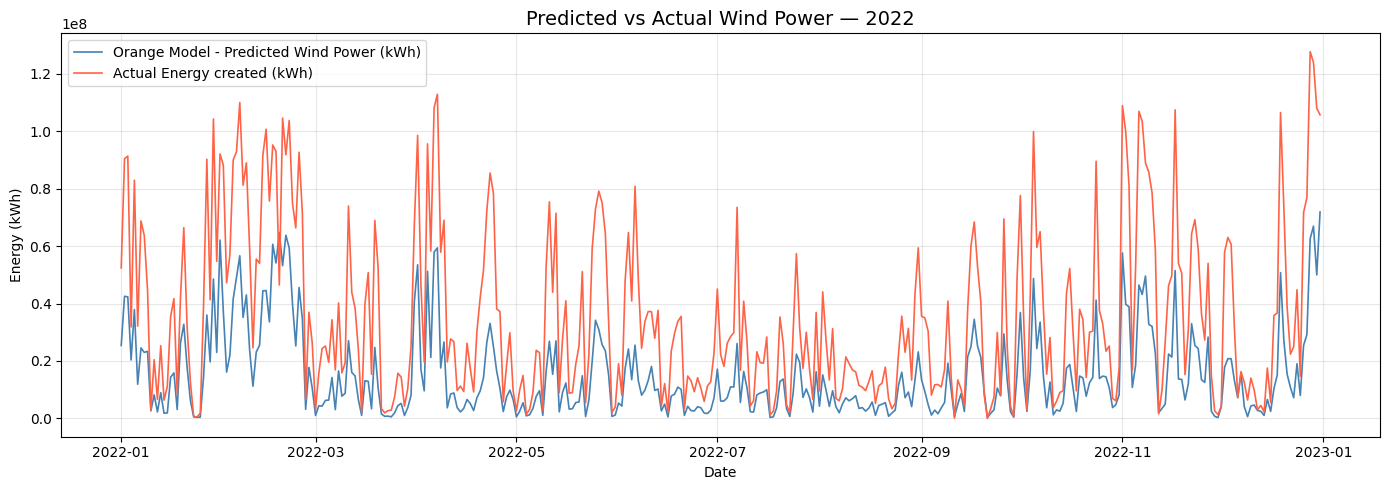

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_merged['date'], df_merged['Orange Model - Predicted Wind Power (kWh)'],
        color='steelblue', label='Orange Model - Predicted Wind Power (kWh)', linewidth=1.2)

ax.plot(df_merged['date'], df_merged['Actual Energy created (kWh)'],
        color='tomato', label='Actual Energy created (kWh)', linewidth=1.2)

ax.set_title('Predicted vs Actual Wind Power — 2022', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (kWh)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

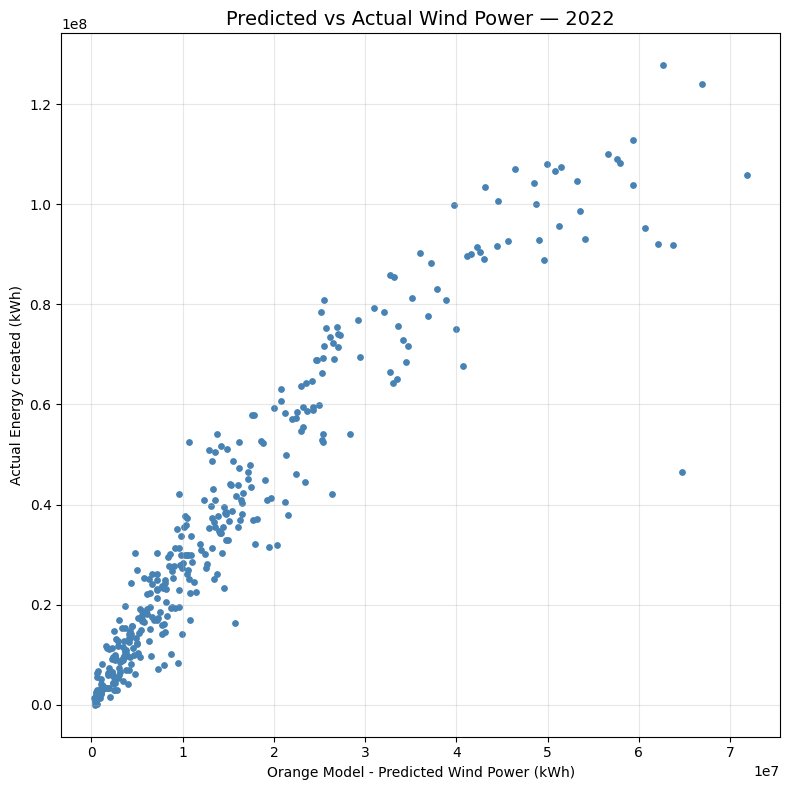

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df_merged['Orange Model - Predicted Wind Power (kWh)'],
           df_merged['Actual Energy created (kWh)'],
           color='steelblue', s=15)

ax.set_title('Predicted vs Actual Wind Power — 2022', fontsize=14)
ax.set_xlabel('Orange Model - Predicted Wind Power (kWh)')
ax.set_ylabel('Actual Energy created (kWh)')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()